# Toy DAG demo

Two `Source` artifacts feeding one `CombinedSource`. Run once to see both
downloads plus the combine step fire; run again to see nothing scheduled.

In [1]:
from pathlib import Path

from artifact import CombinedSource, Source
from resolve import job_list, resolve, run_all

root = Path("../data_demo")  # kept separate from the real /data tree

In [2]:
odyssey = Source(name="odyssey", url="https://example.com/odyssey.txt")
mobydick = Source(name="mobydick", url="https://example.com/mobydick.txt")
combined = CombinedSource(sources=(odyssey, mobydick))

In [11]:
manifest = resolve(combined)
manifest

{'artifact': CombinedSource(sources=(Source(name='odyssey', url='https://example.com/odyssey.txt'), Source(name='mobydick', url='https://example.com/mobydick.txt'))),
 'job': <job.CombineJob at 0x103697650>,
 'outputs': [CombinedSource(sources=(Source(name='odyssey', url='https://example.com/odyssey.txt'), Source(name='mobydick', url='https://example.com/mobydick.txt')))],
 'inputs': [{'artifact': Source(name='odyssey', url='https://example.com/odyssey.txt'),
   'job': <job.SourceJob at 0x103696ff0>,
   'outputs': [Source(name='odyssey', url='https://example.com/odyssey.txt')],
   'inputs': []},
  {'artifact': Source(name='mobydick', url='https://example.com/mobydick.txt'),
   'job': <job.SourceJob at 0x103697410>,
   'outputs': [Source(name='mobydick', url='https://example.com/mobydick.txt')],
   'inputs': []}]}

In [12]:
[job.outputs[0].relpath() for job in job_list(manifest)]  # execution order, dependencies first

[PosixPath('odyssey/body.txt'),
 PosixPath('mobydick/body.txt'),
 PosixPath('odyssey-mobydick/combined.txt')]

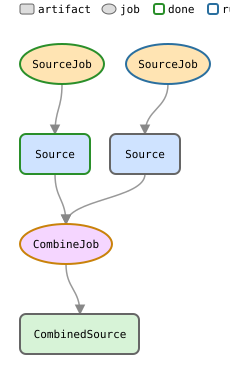

In [14]:
from visualizer import visualize

visualize(manifest, root)  # boxes = artifacts, ellipses = jobs; outline = status

In [6]:
run_all(combined, root)  # first run: downloads both sources, then combines

skip  odyssey/body.txt  (already done)
skip  mobydick/body.txt  (already done)
skip  odyssey-mobydick/combined.txt  (already done)


In [7]:
print(combined.path(root).read_text())

[odyssey] fetched from https://example.com/odyssey.txt
[mobydick] fetched from https://example.com/mobydick.txt



In [8]:
run_all(combined, root)  # second run: everything already exists, nothing scheduled

skip  odyssey/body.txt  (already done)
skip  mobydick/body.txt  (already done)
skip  odyssey-mobydick/combined.txt  (already done)


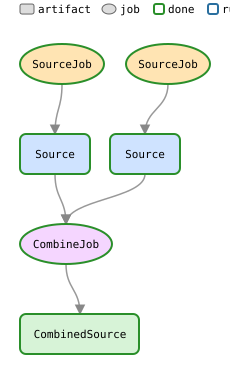

In [9]:
visualize(manifest, root)  # now everything's done -- all outlines green